### Exploratory Data

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
h5_file = h5py.File('../data/fafb/fafb_v14_ffn1_z2000-6096.h5', 'r')
image = h5_file['image']
segment = h5_file['annotations']
i = 15
print(f"Image shape: {image.shape}")
print(f"Segment shape: {segment.shape}")
img_slice = np.array(image[i, :4096, :4096])
seg_slice = np.array(segment[i, :4096, :4096])

# Segment IDs are large uint64 values; remap to a small palette so each neuron
# gets a visually distinct colour instead of a near-identical grey level.
rng = np.random.default_rng(42)
palette = rng.integers(0, 256, size=(256, 3), dtype=np.uint8)
palette[0] = 0  # background stays black
seg_rgb = palette[seg_slice % 256]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_slice, cmap='gray')
ax.imshow(seg_rgb, alpha=0.5)
ax.set_title('Image + segment overlay')
plt.tight_layout()
plt.show()

### Blocking the huge volume

In [45]:
import os
import numpy as np
from tifffile import imwrite
from tqdm import tqdm

def save_blocks_to_tif(image, segment, block_size=64, output_dir='../data/fafb/blocks'):
    os.makedirs(output_dir, exist_ok=True)
    z_dim, y_dim, x_dim = image.shape

    n_z = (z_dim + block_size - 1) // block_size
    n_y = (y_dim + block_size - 1) // block_size
    n_x = (x_dim + block_size - 1) // block_size
    total = n_z * n_y * n_x

    with tqdm(total=total, unit='block', desc='Saving blocks') as pbar:
        for zi in range(n_z):
            for yi in range(n_y):
                for xi in range(n_x):
                    img_path = os.path.join(output_dir, f'image_z{zi}_y{yi}_x{xi}.tif')
                    seg_path = os.path.join(output_dir, f'segment_z{zi}_y{yi}_x{xi}.tif')

                    if os.path.exists(img_path) and os.path.exists(seg_path):
                        pbar.update(1)
                        continue

                    z, y, x = zi * block_size, yi * block_size, xi * block_size
                    img_block = np.array(image   [z:z+block_size, y:y+block_size, x:x+block_size])
                    seg_block = np.array(segment [z:z+block_size, y:y+block_size, x:x+block_size])

                    if not os.path.exists(img_path):
                        imwrite(img_path, img_block)
                    if not os.path.exists(seg_path):
                        imwrite(seg_path, seg_block)

                    pbar.update(1)

save_blocks_to_tif(image, segment)

Saving blocks: 100%|██████████| 262144/262144 [2:28:42<00:00, 29.38block/s]  


### Read the blocks

Text(0.5, 1.0, 'block : image_z0_y0_x0')

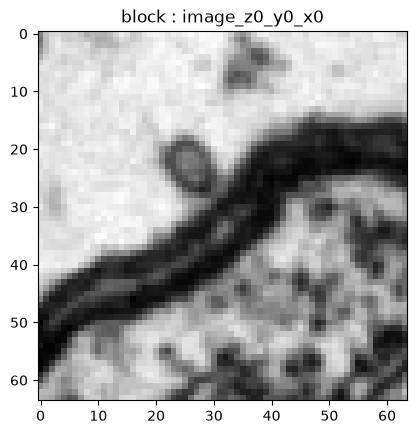

In [7]:
from tifffile import imread
import os
import matplotlib.pyplot as plt
img_dir = '../data/fafb/blocks/image_z0_y0_x0.tif'
img = imread(img_dir)
plt.imshow(img[31, :, :], cmap='gray')
plt.title(f'block : {os.path.split(img_dir)[-1].split(".")[0]}')

### Rename the files

In [ ]:
# from tqdm import tqdm
# # rename tif files to switch names from (64, 0, 0) (128, 0, 0)  ... (4096, 4096, 4096) to (0, 0, 0), (1, 0, 0), ... , (63, 63, 63) with continue capability by checking existed files in the output directory
# def rename_tif_files(input_dir='../data/fafb/blocks', output_dir='../data/fafb/blocks_renamed'):
#     import os
#     from tifffile import imwrite, imread

#     os.makedirs(output_dir, exist_ok=True)

#     for filename in tqdm(os.listdir(input_dir), desc="Processing files"):
#         # but it is not showing the skipped files in the tqdm progress bar, so we need to add a check for that
#         if filename.endswith('.tif'):
#             # Check if the file already exists in the output directory
#             if os.path.exists(os.path.join(output_dir, filename)):
#                 print(f"File {filename} already exists in the output directory. Skipping...")
#                 continue

#             # Extract the original coordinates from the filename
#             parts = filename.split('_')
#             z = int(parts[1][1:])
#             y = int(parts[2][1:])
#             x = int(parts[3][1:].split('.')[0])

#             # Calculate the new coordinates based on block size (64)
#             new_z = z // 64
#             new_y = y // 64
#             new_x = x // 64

#             # Create the new filename and remove the blocks tif images

#             new_filename = f'image_z{new_z}_y{new_y}_x{new_x}.tif'

#             # After renaming remove the original file from the input directory
#             if not os.path.exists(os.path.join(output_dir, new_filename)):
#                 print(f"File {new_filename} already exists in the output directory. Skipping...")
#                 img_block = imread(os.path.join(input_dir, filename))
#                 imwrite(os.path.join(output_dir, new_filename), img_block)
#             # Remove the original file from the input directory
#             os.remove(os.path.join(input_dir, filename))
# rename_tif_files()

### Read a block

Text(0.5, 1.0, 'block : image_z20_y0_x0')

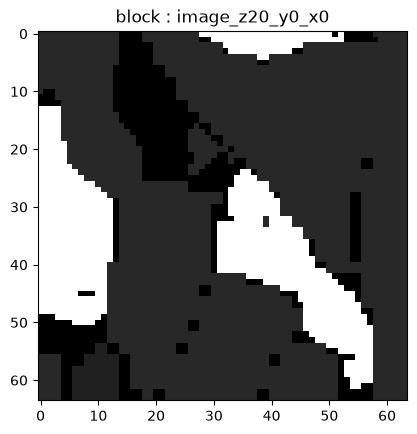

In [ ]:
# from tifffile import imread
# import os
# import matplotlib.pyplot as plt
# new_z, new_y, new_x = 0, 0, 0
# output_dir = '../data/fafb/blocks_renamed'
# img =  f'image_z{20}_y{new_y}_x{new_x}.tif'
# img_dir = os.path.join(output_dir, img)
# img = imread(img_dir)
# plt.imshow(img[1, :, :], cmap='gray')
# plt.title(f'block : {os.path.split(img_dir)[-1].split(".")[0]}')